In [ ]:
!pip install yfinance --upgrade --no-cache-dir

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader as data

import yfinance as yf

In [2]:
start = '2010-01-01'
end = '2024-12-31'

# Use yfinance to download data instead of pandas_datareader
df = yf.download('AAPL', start=start, end=end)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.440330,6.455075,6.391277,6.422875,493729600
2010-01-05,6.451467,6.487880,6.417460,6.458087,601904800
2010-01-06,6.348847,6.477046,6.342227,6.451467,552160000
2010-01-07,6.337110,6.379843,6.291067,6.372319,477131200
2010-01-08,6.379241,6.379843,6.291368,6.328684,447610800


In [3]:
df.shape

(3773, 5)

In [4]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-12-23,254.989655,255.369227,253.171646,254.490204,40858800
2024-12-24,257.916443,257.926411,255.009620,255.209412,23234700
2024-12-26,258.735504,259.814335,257.347047,257.906429,27237100
2024-12-27,255.309296,258.415896,252.782075,257.546826,42355300
2024-12-30,251.923019,253.221595,250.474615,251.952985,35557500


In [5]:
df = df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2010-01-04,6.440330,6.455075,6.391277,6.422875,493729600
1,2010-01-05,6.451467,6.487880,6.417460,6.458087,601904800
2,2010-01-06,6.348847,6.477046,6.342227,6.451467,552160000
3,2010-01-07,6.337110,6.379843,6.291067,6.372319,477131200
4,2010-01-08,6.379241,6.379843,6.291368,6.328684,447610800


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3773 entries, 0 to 3772
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        3773 non-null   datetime64[ns]
 1   (Close, AAPL)   3773 non-null   float64       
 2   (High, AAPL)    3773 non-null   float64       
 3   (Low, AAPL)     3773 non-null   float64       
 4   (Open, AAPL)    3773 non-null   float64       
 5   (Volume, AAPL)  3773 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 177.0 KB


In [7]:
# Assuming your DataFrame is named df
# Assuming your DataFrame is named df
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']



In [8]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2010-01-04,6.440330,6.455075,6.391277,6.422875,493729600
1,2010-01-05,6.451467,6.487880,6.417460,6.458087,601904800
2,2010-01-06,6.348847,6.477046,6.342227,6.451467,552160000
3,2010-01-07,6.337110,6.379843,6.291067,6.372319,477131200
4,2010-01-08,6.379241,6.379843,6.291368,6.328684,447610800


In [9]:
df = df.drop(['Date'],axis=1)
df.head()

,Close,High,Low,Open,Volume
0,6.440330,6.455075,6.391277,6.422875,493729600
1,6.451467,6.487880,6.417460,6.458087,601904800
2,6.348847,6.477046,6.342227,6.451467,552160000
3,6.337110,6.379843,6.291067,6.372319,477131200
4,6.379241,6.379843,6.291368,6.328684,447610800


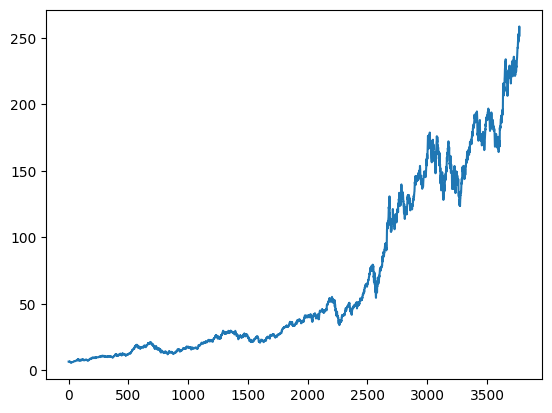

In [10]:
plt.plot(df.Close)

In [11]:
df

,Close,High,Low,Open,Volume
0,6.440330,6.455075,6.391277,6.422875,493729600
1,6.451467,6.487880,6.417460,6.458087,601904800
2,6.348847,6.477046,6.342227,6.451467,552160000
3,6.337110,6.379843,6.291067,6.372319,477131200
4,6.379241,6.379843,6.291368,6.328684,447610800
...,...,...,...,...,...
3768,254.989655,255.369227,253.171646,254.490204,40858800
3769,257.916443,257.926411,255.009620,255.209412,23234700
3770,258.735504,259.814335,257.347047,257.906429,27237100
3771,255.309296,258.415896,252.782075,257.546826,42355300


In [12]:
ma100  = df.Close.rolling(100).mean()
ma100

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
3768,228.969606
3769,229.357535
3770,229.859200
3771,230.346935


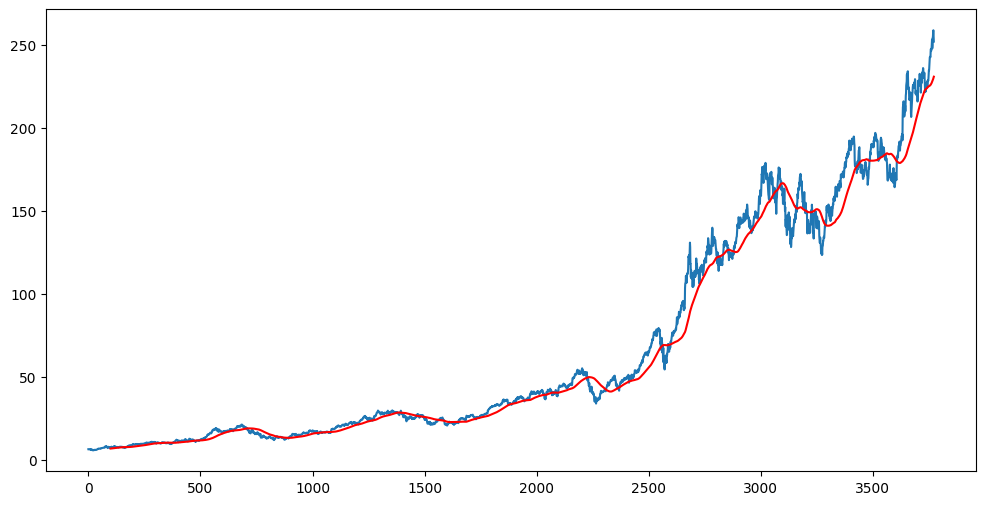

In [13]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')

In [14]:
ma200  = df.Close.rolling(200).mean()
ma200

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
3768,210.752679
3769,211.182570
3770,211.614169
3771,212.039086


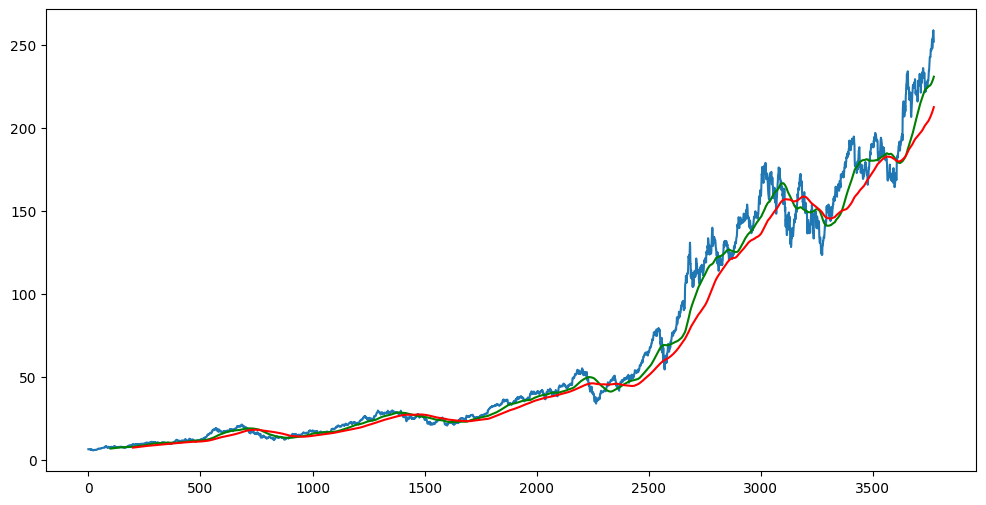

In [15]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100,'green')
plt.plot(ma200,'r')

In [16]:
df.shape

(3773, 5)

In [17]:
# Splitting Data into Traing and Testing
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])

print(data_training.shape)
print(data_testing.shape)

(2641, 1)
(1132, 1)


In [18]:
 data_training.head()

,Close
0,6.440330
1,6.451467
2,6.348847
3,6.337110
4,6.379241


In [19]:
data_testing.head()

,Close
2641,88.601036
2642,88.601036
2643,90.971161
2644,90.688896
2645,92.801033


In [20]:
from sklearn .preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [21]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.00792292],
       [0.00805644],
       [0.00682614],
       ...,
       [0.96236637],
       [0.98614258],
       [0.99495297]])

In [22]:
data_training_array.shape

(2641, 1)

In [23]:
x_train = []
y_train = []

for i in range(100,data_training_array.shape[0]):
  x_train.append(data_training_array[i-100:i])
  y_train.append(data_training_array[i,0])

x_train,y_train = np.array(x_train),np.array(y_train)

In [24]:
x_train.shape

(2541, 100, 1)

In [27]:
x_train

array([[[0.00792292],
        [0.00805644],
        [0.00682614],
        ...,
        [0.01973876],
        [0.01918316],
        [0.0187827 ]],

       [[0.00805644],
        [0.00682614],
        [0.00668542],
        ...,
        [0.01918316],
        [0.0187827 ],
        [0.02211637]],

       [[0.00682614],
        [0.00668542],
        [0.00719053],
        ...,
        [0.0187827 ],
        [0.02211637],
        [0.02338999]],

       ...,

       [[0.85619404],
        [0.8637408 ],
        [0.8746545 ],
        ...,
        [1.        ],
        [0.9811251 ],
        [0.99506969]],

       [[0.8637408 ],
        [0.8746545 ],
        [0.86182363],
        ...,
        [0.9811251 ],
        [0.99506969],
        [0.96236637]],

       [[0.8746545 ],
        [0.86182363],
        [0.86624593],
        ...,
        [0.99506969],
        [0.96236637],
        [0.98614258]]])

In [26]:
y_train

array([0.02211637, 0.02338999, 0.02481505, ..., 0.96236637, 0.98614258,
       0.99495297])

In [25]:
y_train.shape

(2541,)

In [ ]:
# Applying the ML model
from keras.layers import Dense,Dropout,LSTM
from keras.models import Sequential


In [ ]:
model = Sequential()
model.add(LSTM(units=50,activation='relu',return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))


model.add(LSTM(units=60,activation='relu',return_sequences=True))
model.add(Dropout(0.3))


model.add(LSTM(units=80,activation='relu',return_sequences=True))
model.add(Dropout(0.4))


model.add(LSTM(units=120,activation='relu'))
model.add(Dropout(0.5))


model.add(Dense(units = 1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(x_train,y_train,epochs=100)

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 32s 289ms/step - loss: 0.0035
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 340ms/step - loss: 0.0030
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 301ms/step - loss: 0.0029
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 316ms/step - loss: 0.0023
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 315ms/step - loss: 0.0025
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 288ms/step - loss: 0.0024
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 307ms/step - loss: 0.0022
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 310ms/step - loss: 0.0025
Epoch 9/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 316ms/step - loss: 0.0021
Epoch 10/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 315ms/step - loss: 0.0026
Epoch 11/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 336ms/step - loss: 0.0021
Epoch 12/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 293ms/step - loss: 0.0022
Epoch 13/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 309ms/step - loss: 0.0025
Epoch 14/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 318ms/step - loss: 0.0020
Epoch 15/100
80/80 ━━━━━━━━━━

In [ ]:
model.save('keras_model.h5')

In [ ]:
data_testing.head()

,Close
2641,88.698463
2642,88.698463
2643,91.071159
2644,90.788589
2645,92.903038


In [ ]:
data_training.tail(100)

,Close
2541,77.749954
2542,78.119240
2543,77.647919
2544,79.491882
2545,78.925819
...,...
2636,87.711891
2637,88.876305
2638,86.145523
2639,88.130882


In [ ]:
past_100_days = data_training.tail(100)

In [ ]:
# final_df = past_100_days.append(data_testing,ignore_index=True)

In [ ]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [ ]:
final_df.head()

,Close
0,77.749954
1,78.119240
2,77.647919
3,79.491882
4,78.925819


In [ ]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.11363831],
       [0.11544401],
       [0.11313938],
       ...,
       [1.        ],
       [0.98322826],
       [0.96665207]])

In [ ]:
input_data.shape

(1232, 1)

In [ ]:
x_test = []
y_test = []

for i in range(100,input_data.shape[0]):
  x_test.append(input_data[i-100:i])
  y_test.append(input_data[i,0])

In [ ]:
x_test, y_test = np.array(x_test),np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(1132, 100, 1)
(1132,)


In [ ]:
# making predictions

y_predicted = model.predict(x_test)

36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 152ms/step


In [ ]:
y_predicted.shape

(1132, 1)

In [ ]:
y_test

array([0.16717357, 0.16717357, 0.17877541, ..., 1.        , 0.98322826,
       0.96665207])

In [ ]:
y_predicted

array([[0.17208014],
       [0.1739342 ],
       [0.1756561 ],
       ...,
       [0.9243634 ],
       [0.9286447 ],
       [0.9327902 ]], dtype=float32)

In [ ]:
scaler.scale_

array([0.00488973])

In [ ]:
scale_factor = 1/scaler.scale_[0]
y_predicted = y_predicted * scale_factor
y_test = y_test * scale_factor

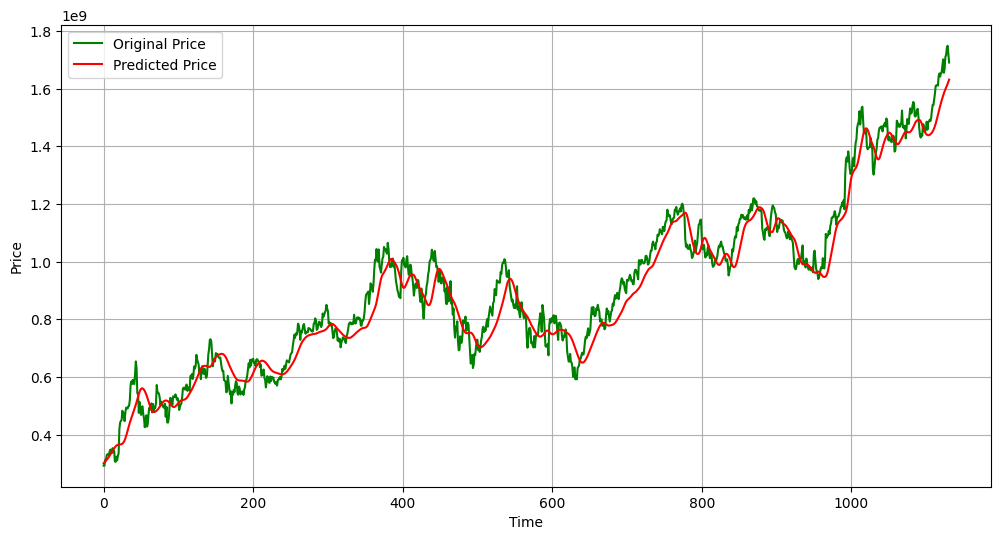

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'g',label='Original Price')
plt.plot(y_predicted,'r',label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid()